In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [13]:
# Change working directory to project root when running from notebooks folder
if os.path.basename(os.getcwd()).lower() == 'notebooks':
    os.chdir('..')

# Read the cleaned CSV file created by scripts/preprocess.py
gym_df = pd.read_csv('data/processed/rutgers_gym_cleaned.csv')

gym_df.head()

,gym_name,day_of_week,hour,busyness_percent,hour_24,is_weekend,semester_week,is_exam_week,weather,capacity_label
0,College Avenue Gym,Monday,7:00 AM,15,7,False,1,False,rain,Low
1,College Avenue Gym,Monday,8:00 AM,25,8,False,1,False,rain,Low
2,College Avenue Gym,Monday,9:00 AM,28,9,False,1,False,rain,Low
3,College Avenue Gym,Monday,10:00 AM,23,10,False,1,False,rain,Low
4,College Avenue Gym,Monday,11:00 AM,20,11,False,1,False,rain,Low


In [14]:
# Check columns and target distribution
print(gym_df.columns.tolist())
print('\nCapacity label counts:')
print(gym_df['capacity_label'].value_counts())

['gym_name', 'day_of_week', 'hour', 'busyness_percent', 'hour_24', 'is_weekend', 'semester_week', 'is_exam_week', 'weather', 'capacity_label']

Capacity label counts:
capacity_label
Low       166
Medium    123
High       42
Name: count, dtype: int64


In [15]:
# Select columns as features for the model
categorical_features = ['gym_name', 'day_of_week', 'weather']
numeric_features = ['hour_24', 'is_weekend', 'semester_week', 'is_exam_week']

features = categorical_features + numeric_features

# x contains input data, y contains the target labels
X = gym_df[features].copy()
y = gym_df['capacity_label']

# convert boolean columns to integers so they work with StandardScaler
X['is_weekend'] = X['is_weekend'].astype(int)
X['is_exam_week'] = X['is_exam_week'].astype(int)

print('Input shape:', X.shape)
print('Target shape:', y.shape)

Input shape: (331, 7)
Target shape: (331,)


In [16]:
# Split data training
# stratify=y keeps Low/Medium/High proportions similar in train and test data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Training rows:', len(X_train))
print('Testing rows:', len(X_test))

Training rows: 264
Testing rows: 67


In [17]:
# One-hot encode categorical columns and scale numeric columns
preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('numeric', StandardScaler(), numeric_features)
    ]
)

# predicts one of the capacity classes: Low, Medium, or High
# class_weight='balanced' helps cuz high class appears less often in the dataset
log_reg_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

# train model on training data
log_reg_model.fit(X_train, y_train)

print('Logistic regression model trained successfully')

Logistic regression model trained successfully


In [18]:
# use trained model to predict test data
y_pred = log_reg_model.predict(X_test)

# calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# convert ordered capacity labels to numbers so MAE/RMSE can be compared with random forest notebook
capacity_to_number = {'Low': 0, 'Medium': 1, 'High': 2}
y_test_numbers = y_test.map(capacity_to_number)
y_pred_numbers = pd.Series(y_pred).map(capacity_to_number)

# calculate MAE and RMSE
mae = mean_absolute_error(y_test_numbers, y_pred_numbers)
rmse = np.sqrt(mean_squared_error(y_test_numbers, y_pred_numbers))

print('Accuracy:', round(accuracy * 100, 2), '%')
print('MAE:', round(mae, 3))
print('RMSE:', round(rmse, 3))

Accuracy: 73.13 %
MAE: 0.358
RMSE: 0.733


In [19]:
# more detailed classification metrics
capacity_order = ['Low', 'Medium', 'High']

print(classification_report(y_test, y_pred, labels=capacity_order, zero_division=0))

              precision    recall  f1-score   support

         Low       0.96      0.68      0.79        34
      Medium       0.74      0.80      0.77        25
        High       0.38      0.75      0.50         8

    accuracy                           0.73        67
   macro avg       0.69      0.74      0.69        67
weighted avg       0.81      0.73      0.75        67



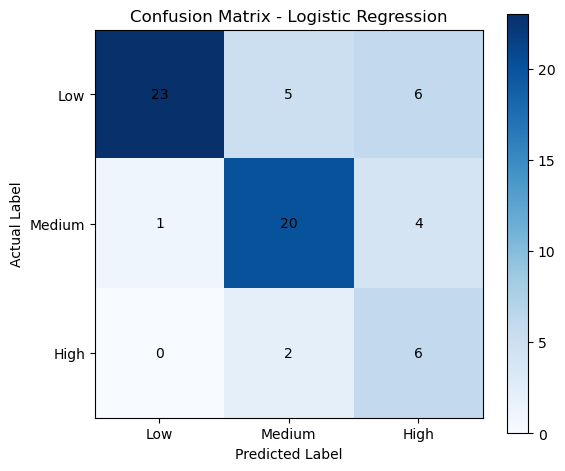

In [20]:
# confusion matrix shows which capacity labels the model mixes up
cm = confusion_matrix(y_test, y_pred, labels=capacity_order)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.xticks(range(len(capacity_order)), capacity_order)
plt.yticks(range(len(capacity_order)), capacity_order)
plt.colorbar()

for row in range(len(capacity_order)):
    for col in range(len(capacity_order)):
        plt.text(col, row, cm[row, col], ha='center', va='center', color='black')

plt.tight_layout()
plt.show()

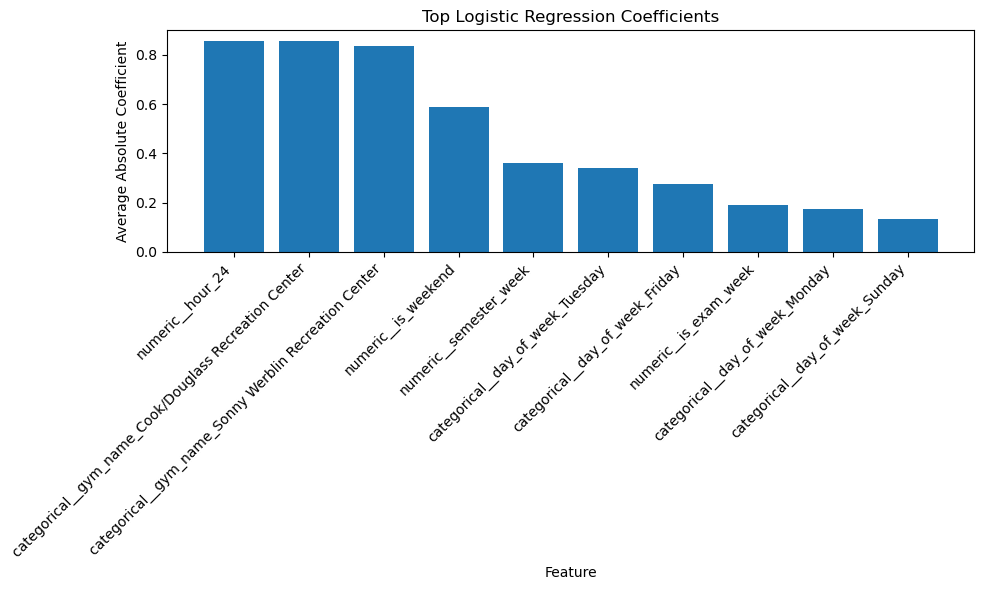

In [21]:
# show which features help push predictions toward a class
encoded_feature_names = log_reg_model.named_steps['preprocess'].get_feature_names_out()
coefficients = log_reg_model.named_steps['model'].coef_

# average absolute coefficient size across the three classes
importance = np.mean(np.abs(coefficients), axis=0)
importance_df = pd.DataFrame({
    'feature': encoded_feature_names,
    'importance': importance
}).sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.bar(importance_df['feature'], importance_df['importance'])
plt.title('Top Logistic Regression Coefficients')
plt.xlabel('Feature')
plt.ylabel('Average Absolute Coefficient')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [22]:
# example prediction using the trained model
sample_request = pd.DataFrame([{
    'gym_name': 'College Avenue Gym',
    'day_of_week': 'Monday',
    'weather': 'rain',
    'hour_24': 18,
    'is_weekend': 0,
    'semester_week': 10,
    'is_exam_week': 0
}])

predicted_capacity = log_reg_model.predict(sample_request)[0]
predicted_probabilities = log_reg_model.predict_proba(sample_request)[0]

print('Predicted capacity:', predicted_capacity)
print('\nPrediction probabilities:')
for label, probability in zip(log_reg_model.classes_, predicted_probabilities):
    print(label + ':', round(probability * 100, 2), '%')

Predicted capacity: Low

Prediction probabilities:
High: 28.06 %
Low: 44.46 %
Medium: 27.49 %
